In [7]:
with open("../data/ethiopia.csv", "r") as f:
    lines = f.readlines()

lines[:30]


['-BEGIN HEADER-\n',
 'NASA/POWER Source Native Resolution Daily Data \n',
 'Dates (month/day/year): 01/01/2020 through 01/31/2020 in LST\n',
 'Location: latitude  9.145   longitude 40.4897 \n',
 'elevation from MERRA-2: Average for 0.5 x 0.625 degree lat/lon region = 1540.12 meters\n',
 'The value for missing source data that cannot be computed or is outside of the sources availability range: -999 \n',
 'parameter(s): \n',
 'T2M             MERRA-2 Temperature at 2 Meters (C) \n',
 'PRECTOTCORR     MERRA-2 Precipitation Corrected (mm/day) \n',
 'RH2M            MERRA-2 Relative Humidity at 2 Meters (%) \n',
 'WS2M            MERRA-2 Wind Speed at 2 Meters (m/s) \n',
 'T2M_MAX         MERRA-2 Temperature at 2 Meters Maximum (C) \n',
 'T2M_MIN         MERRA-2 Temperature at 2 Meters Minimum (C) \n',
 '-END HEADER-\n',
 'YEAR,MO,DY,T2M,PRECTOTCORR,RH2M,WS2M,T2M_MAX,T2M_MIN\n',
 '2020,1,1,19.25,0.06,73.85,1.57,25.45,14.45\n',
 '2020,1,2,20.74,0.05,66.21,1.17,27.14,15.69\n',
 '2020,1,3,20.

In [2]:
import streamlit as st
st.image("dashboard_screenshots/image.png")

2026-04-29 02:46:14.090 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


RuntimeError: Runtime hasn't been created!

In [13]:
import pandas as pd
from io import StringIO

with open("../data/ethiopia.csv", "r", encoding="utf-8") as f:
    lines = f.readlines()

# keep only real data rows (start from YEAR lines)
data_lines = [line for line in lines if line[0].isdigit()]

df = pd.read_csv(StringIO("".join(data_lines)))

df.head()

,2020,1,1.1,19.25,0.06,73.85,1.57,25.45,14.45
0,2020,1,2,20.74,0.05,66.21,1.17,27.14,15.69
1,2020,1,3,20.27,0.08,70.78,1.29,26.08,16.28
2,2020,1,4,19.92,0.04,65.74,1.19,26.61,14.99
3,2020,1,5,20.37,0.01,60.14,1.06,27.15,14.85
4,2020,1,6,19.76,0.01,63.17,1.53,27.57,13.02


In [14]:
import numpy as np

df = df.replace(-999, np.nan)
df.isna().sum()

2020     0
1        0
1.1      0
19.25    0
0.06     0
73.85    0
1.57     0
25.45    0
14.45    0
dtype: int64

In [17]:
df.duplicated().sum()
df = df.drop_duplicates()

In [18]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df.head()

KeyError: 'YEAR'

In [19]:
df.columns

Index(['2020', '1', '1.1', '19.25', '0.06', '73.85', '1.57', '25.45', '14.45'], dtype='str')

In [20]:
df.columns = df.columns.str.strip()
df.columns

Index(['2020', '1', '1.1', '19.25', '0.06', '73.85', '1.57', '25.45', '14.45'], dtype='str')

In [23]:
print(df.head())
print(df.columns)

   2020  1  1.1  19.25  0.06  73.85  1.57  25.45  14.45
0  2020  1    2  20.74  0.05  66.21  1.17  27.14  15.69
1  2020  1    3  20.27  0.08  70.78  1.29  26.08  16.28
2  2020  1    4  19.92  0.04  65.74  1.19  26.61  14.99
3  2020  1    5  20.37  0.01  60.14  1.06  27.15  14.85
4  2020  1    6  19.76  0.01  63.17  1.53  27.57  13.02
Index(['2020', '1', '1.1', '19.25', '0.06', '73.85', '1.57', '25.45', '14.45'], dtype='str')


In [32]:
for col in df.columns:
    print(col)

2020
1
1.1
19.25
0.06
73.85
1.57
25.45
14.45


In [38]:
df.columns = df.columns.str.strip().str.upper()
print(df.columns)

Index(['2020', '1', '1.1', '19.25', '0.06', '73.85', '1.57', '25.45', '14.45'], dtype='str')


In [40]:
df.columns = [
    "YEAR", "MONTH_NUM", "DAY",
    "T2M", "PRECTOTCORR", "RH2M", "WS2M", "T2M_MAX", "T2M_MIN"
]
df.head()

,YEAR,MONTH_NUM,DAY,T2M,PRECTOTCORR,RH2M,WS2M,T2M_MAX,T2M_MIN
0,2020,1,2,20.74,0.05,66.21,1.17,27.14,15.69
1,2020,1,3,20.27,0.08,70.78,1.29,26.08,16.28
2,2020,1,4,19.92,0.04,65.74,1.19,26.61,14.99
3,2020,1,5,20.37,0.01,60.14,1.06,27.15,14.85
4,2020,1,6,19.76,0.01,63.17,1.53,27.57,13.02


In [46]:
df["DATE"] = pd.to_datetime(
    df["YEAR"].astype(int).astype(str) + "-" +
    df["MONTH_NUM"].astype(int).astype(str) + "-" +
    df["DAY"].astype(int).astype(str),
    errors="coerce"
)

df.head()

,YEAR,MONTH_NUM,DAY,T2M,PRECTOTCORR,RH2M,WS2M,T2M_MAX,T2M_MIN,DATE
0,2020,1,2,20.74,0.05,66.21,1.17,27.14,15.69,2020-01-02
1,2020,1,3,20.27,0.08,70.78,1.29,26.08,16.28,2020-01-03
2,2020,1,4,19.92,0.04,65.74,1.19,26.61,14.99,2020-01-04
3,2020,1,5,20.37,0.01,60.14,1.06,27.15,14.85,2020-01-05
4,2020,1,6,19.76,0.01,63.17,1.53,27.57,13.02,2020-01-06


In [47]:
import numpy as np

df = df.replace(-999, np.nan)
df.isna().sum()

YEAR           0
MONTH_NUM      0
DAY            0
T2M            0
PRECTOTCORR    0
RH2M           0
WS2M           0
T2M_MAX        0
T2M_MIN        0
DATE           0
dtype: int64

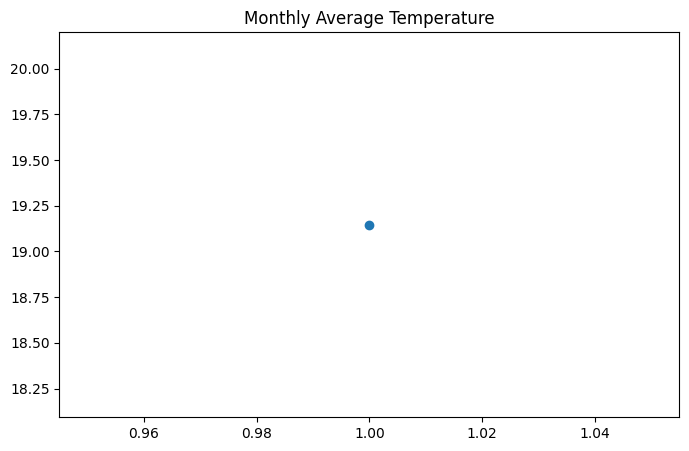

In [53]:
monthly_temp = df.groupby("MONTH")["T2M"].mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(monthly_temp, marker="o")
plt.title("Monthly Average Temperature")
plt.show()

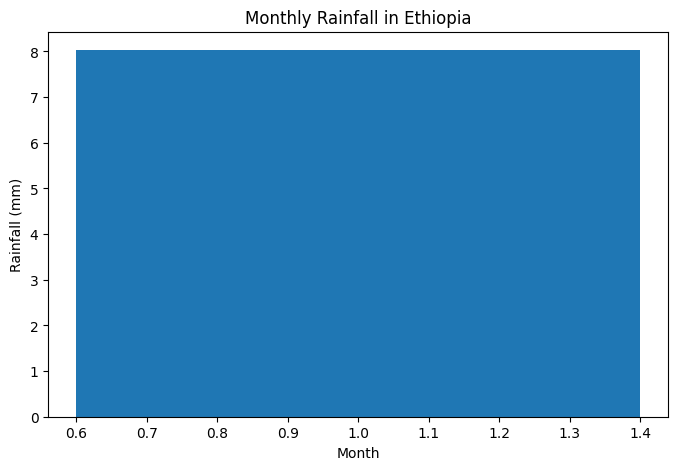

In [54]:
monthly_rain = df.groupby("MONTH")["PRECTOTCORR"].sum()

plt.figure(figsize=(8,5))
plt.bar(monthly_rain.index, monthly_rain)
plt.title("Monthly Rainfall in Ethiopia")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.show()

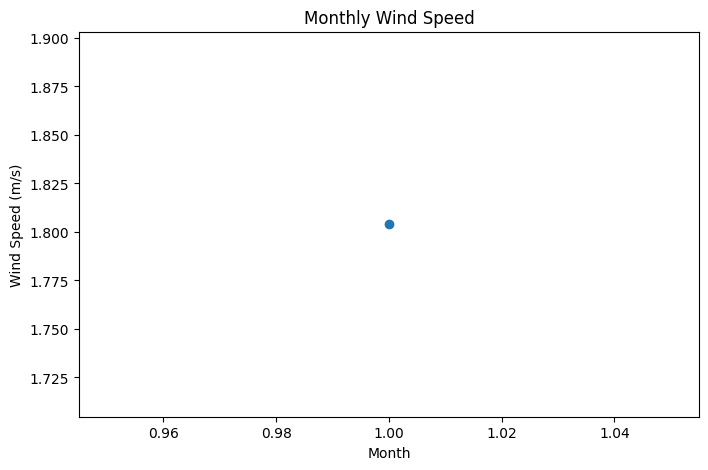

In [55]:
monthly_wind = df.groupby("MONTH")["WS2M"].mean()

plt.figure(figsize=(8,5))
plt.plot(monthly_wind, marker="o")
plt.title("Monthly Wind Speed")
plt.xlabel("Month")
plt.ylabel("Wind Speed (m/s)")
plt.show()

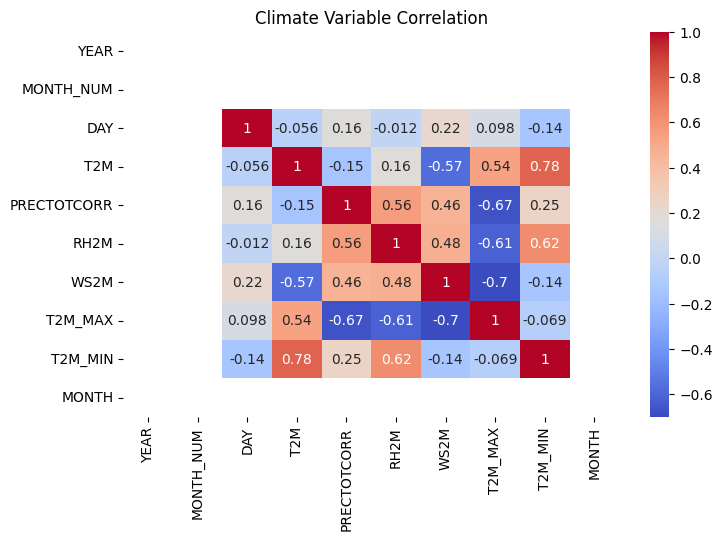

In [56]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Climate Variable Correlation")
plt.show()

In [ ]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

: 

In [24]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         8 non-null      int64  
 1   DOY          8 non-null      int64  
 2   T2M          8 non-null      float64
 3   PRECTOTCORR  8 non-null      float64
 4   RH2M         8 non-null      int64  
 5   WS2M         8 non-null      float64
dtypes: float64(3), int64(3)
memory usage: 516.0 bytes


,YEAR,DOY,T2M,PRECTOTCORR,RH2M,WS2M
count,8.0,8.00000,8.000000,8.000000,8.00000,8.00000
mean,2020.0,4.50000,-101.750000,-123.875000,66.87500,3.65000
std,0.0,2.44949,362.545497,353.605805,5.24915,0.40708
min,2020.0,1.00000,-999.000000,-999.000000,60.00000,3.00000
25%,2020.0,2.75000,25.025000,0.000000,62.75000,3.42500
50%,2020.0,4.50000,26.250000,0.650000,66.50000,3.70000
75%,2020.0,6.25000,27.125000,1.400000,70.50000,3.92500
max,2020.0,8.00000,28.100000,3.500000,75.00000,4.20000


In [25]:
df = df.replace(-999, np.nan)
df.isna().sum()

YEAR           0
DOY            0
T2M            1
PRECTOTCORR    1
RH2M           0
WS2M           0
dtype: int64

In [26]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [27]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df.head()

,YEAR,DOY,T2M,PRECTOTCORR,RH2M,WS2M,DATE
0,2020,1,25.1,0.0,60,3.2,2020-01-01
1,2020,2,24.8,NaN,62,3.5,2020-01-02
2,2020,3,26.0,1.2,65,3.0,2020-01-03
3,2020,4,27.5,0.5,63,3.8,2020-01-04
4,2020,5,NaN,2.0,70,4.0,2020-01-05


In [28]:
df.to_csv("data/ethiopia_clean.csv", index=False)

OSError: Cannot save file into a non-existent directory: 'data'

In [29]:
monthly_rain = df.groupby("MONTH")["PRECTOTCORR"].sum()

plt.bar(monthly_rain.index, monthly_rain)
plt.title("Monthly Rainfall (Ethiopia)")
plt.xlabel("Month")
plt.ylabel("Rainfall")
plt.show()

KeyError: 'MONTH'

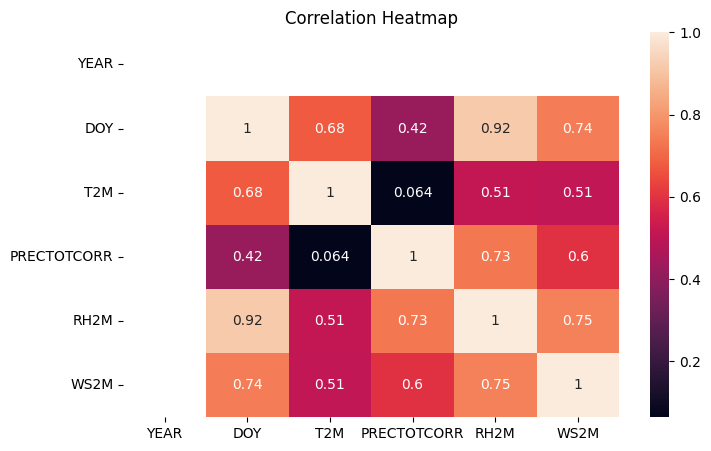

In [30]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()